In [1]:
import pandas as pd

# Load dataset
df = pd.read_json(
    'C:/Users/user/Desktop/Dakshita project/NLP/New Project/News_Category_Dataset_v3.json',
    lines=True
)

# Manual mapping of categories into broader groups
category_map = {
    'ARTS': 'Arts & Culture',
    'ARTS & CULTURE': 'Arts & Culture',
    'CULTURE & ARTS': 'Arts & Culture',
    'WORLDPOST': 'Arts & Culture',
    'THE WORLDPOST': 'Arts & Culture',

    'STYLE': 'Lifestyle',
    'STYLE & BEAUTY': 'Lifestyle',
    'HOME & LIVING': 'Lifestyle',
    'WEDDINGS': 'Lifestyle',
    'DIVORCE': 'Lifestyle',

    'WELLNESS': 'Health & Wellness',
    'HEALTHY LIVING': 'Health & Wellness',
    'FOOD & DRINK': 'Health & Wellness',
    'TASTE': 'Health & Wellness',

    'U.S. NEWS': 'News',
    'WORLD NEWS': 'News',
    'POLITICS': 'News',
    'CRIME': 'News',
    'BUSINESS': 'News',
    'MONEY': 'News',

    'ENTERTAINMENT': 'Entertainment',
    'COMEDY': 'Entertainment',
    'WEIRD NEWS': 'Entertainment',
    'GOOD NEWS': 'Entertainment',

    'SCIENCE': 'Science & Tech',
    'TECH': 'Science & Tech',
    'ENVIRONMENT': 'Science & Tech',
    'GREEN': 'Science & Tech',

    'BLACK VOICES': 'Voices & Identity',
    'LATINO VOICES': 'Voices & Identity',
    'QUEER VOICES': 'Voices & Identity',
    'WOMEN': 'Voices & Identity',
    'IMPACT': 'Voices & Identity',

    'TRAVEL': 'Travel',

    'EDUCATION': 'Education',
    'COLLEGE': 'Education',
    'PARENTS': 'Education',
    'PARENTING': 'Education'
}

# Apply mapping
df['engineered_category'] = df['category'].map(category_map)

# Drop rows where engineered_category is NaN (categories not in mapping)
df = df.dropna(subset=['engineered_category'])

# Keep only important features
reduced_df = df[['headline', 'short_description', 'engineered_category']]

# Save to new CSV file
reduced_df.to_csv(
    'C:/Users/user/Desktop/Dakshita project/NLP/New Project/News_Category_Engineered.csv',
    index=False
)

print("Reduced dataset saved successfully with engineered categories (NaN dropped)!")


Reduced dataset saved successfully with engineered categories (NaN dropped)!


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Load reduced dataset
df = pd.read_csv("C:/Users/user/Desktop/Dakshita project/NLP/New Project/News_Category_Engineered.csv")

# Combine headline + description, replacing NaN with empty string
df['headline'] = df['headline'].fillna("")
df['short_description'] = df['short_description'].fillna("")
df['text'] = df['headline'] + " " + df['short_description']

# Drop rows where engineered_category is NaN (if any slipped through)
df = df.dropna(subset=['engineered_category'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['engineered_category'], test_size=0.2, random_state=42
)

# TF-IDF with bigrams
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# SVM classifier
svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = svm_model.predict(X_test_tfidf)

# Evaluation
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

   Arts & Culture       0.48      0.57      0.52      2053
        Education       0.64      0.72      0.68      3004
    Entertainment       0.69      0.67      0.68      5324
Health & Wellness       0.77      0.78      0.77      6672
        Lifestyle       0.81      0.80      0.80      4672
             News       0.82      0.74      0.78     10288
   Science & Tech       0.47      0.60      0.53      1674
           Travel       0.68      0.78      0.73      1988
Voices & Identity       0.59      0.53      0.56      3831

         accuracy                           0.71     39506
        macro avg       0.66      0.69      0.67     39506
     weighted avg       0.72      0.71      0.71     39506



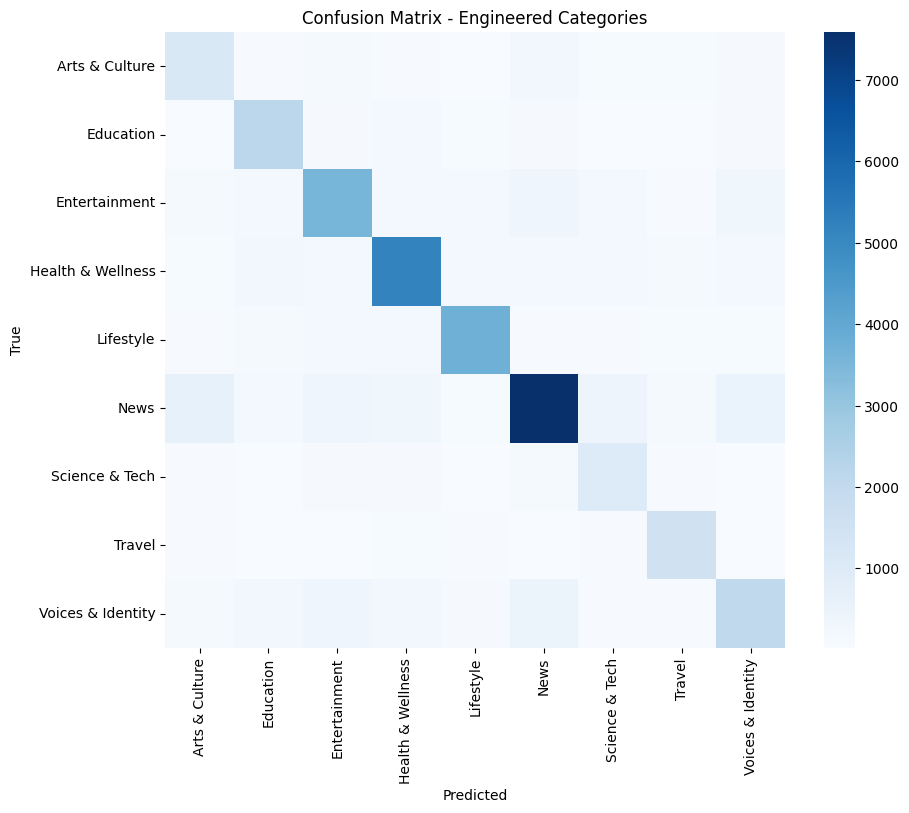

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Engineered Categories")
plt.show()


In [8]:
# Example test headlines
sample_texts = [
    "NASA announces breakthrough in quantum computing",
    "Oscars 2026: Best Picture goes to indie drama",
    "Tips for a healthier lifestyle with yoga",
    "Supreme Court rules on major political case",
    "Top destinations for summer travel in Europe",
    "New study reveals impact of climate change",
    "Celebrating Pride Month across the country"
]

# Transform using the same TF-IDF vectorizer
sample_tfidf = vectorizer.transform(sample_texts)

# Predict categories
sample_preds = svm_model.predict(sample_tfidf)

# Show results
for text, pred in zip(sample_texts, sample_preds):
    print(f"Headline: {text}\nPredicted Category: {pred}\n")


Headline: NASA announces breakthrough in quantum computing
Predicted Category: Science & Tech

Headline: Oscars 2026: Best Picture goes to indie drama
Predicted Category: Entertainment

Headline: Tips for a healthier lifestyle with yoga
Predicted Category: Health & Wellness

Headline: Supreme Court rules on major political case
Predicted Category: News

Headline: Top destinations for summer travel in Europe
Predicted Category: Travel

Headline: New study reveals impact of climate change
Predicted Category: Science & Tech

Headline: Celebrating Pride Month across the country
Predicted Category: Voices & Identity



In [9]:
import joblib

# Save model and vectorizer
joblib.dump(svm_model, "C:/Users/user/Desktop/Dakshita project/NLP/New Project/svm_model.pkl")
joblib.dump(vectorizer, "C:/Users/user/Desktop/Dakshita project/NLP/New Project/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!
